# 0. Environment Setup

In [1]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import sys
sys.path.insert(0, "..")

from src.config import (RAW_DATA_DIR, ROOT_DIR, PROCESSED_DATA_DIR, MODELS_DIR)

# Show all columns 
pd.set_option('display.max_columns', None)

# Bold Text Setup
b_start = '\033[1m'
b_end = '\033[0m'

# Graph visual style
sns.set_theme(style="whitegrid")

print('Environment Ready')

Environment Ready


-----
# 1. Complaint Fraud Related Topics Exploration


In [2]:
# Topic enriched Dataset Load
print('Dataframe Loading...')

df = pd.read_csv(fr'{PROCESSED_DATA_DIR}\topic_enriched_complaints.csv', low_memory=False, delimiter=';')
topics_df = pd.read_csv(fr'{PROCESSED_DATA_DIR}\topic_info.csv', low_memory=False, delimiter=';')

print('Dataframe Correctly Loaded')
print()
display(df.sample(3))
print()
print('Dataframe Correctly Loaded')
print()
display(topics_df.sample(3))

Dataframe Loading...
Dataframe Correctly Loaded



,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,month_received,topic,topic_prob
104189,2018-01-25,Checking or savings account,Checking account,Managing an account,Fee problem,my primary checking account with bank of ameri...,BANK OF AMERICA NATIONAL ASSOCIATION,MD,21122,NaN,Web,2018-01-25,Closed with explanation,Yes,2793940,2018-01-01,-1,0.00000
3419,2021-06-07,Credit card or prepaid card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,i got the citibank in due to a promation givin...,CITIBANK NA,SC,29407,Servicemember,Web,2021-06-07,Closed with explanation,Yes,4438523,2021-06-01,4,0.96298
107319,2021-06-10,Checking or savings account,Checking account,Managing an account,Problem accessing account,i opened a new checking account online but i c...,USBANCORP,WA,98058,NaN,Web,2021-06-10,Closed with explanation,Yes,4448694,2021-06-01,-1,0.00000



Dataframe Correctly Loaded



,topic,count,name,representation,representative_docs
424,423,11,423_regions_confidential_check_body,"['regions', 'confidential', 'check', 'body', '...",['after depositing a personal check from anoth...
4,3,2456,3_coinbase_support_bitcoin_wallet,"['coinbase', 'support', 'bitcoin', 'wallet', '...",['i opened a regular coinbase account on of th...
232,231,34,231_overpayment_checkfree_overpaid_fiserv,"['overpayment', 'checkfree', 'overpaid', 'fise...",['i overpaid by balance by on i was told i wou...


In [3]:
# List of fraud related terms
suspicious_terms = [
    'unauthorized', 'stolen', 'card', 'identity', 'fraud', 
    'atm', 'phishing', 'unsolicited', 'deceptive', 'hack',
    'cash advance', 'scam', 'fake', 'without authorization',
    'unrecognized', 'never', 'error', 'abnormal', 'counterfeit',
    'forged', 'misrepresentation', 'bribe', 'corrupt', 'launder',
    'impersonate', 'impersonating', 'theft', 'hacked', 'breach',
    'unauthorised', 'fraudulent', 'cloned', 'clone', 'skimming'
    'suspicious', 'data leak', 'cyberattack', 'crime', 'criminal',
    'unknown', 'unexpected'
]

# Fraud filtered topic list
fraud_df = topics_df[(topics_df['representation'].apply(lambda x: any(term in x for term in suspicious_terms))) & (topics_df['topic'] != -1)].reset_index(drop=True)
display(fraud_df.info())
display(fraud_df.head())


# Fraud filtered Topics Dataframe Export
file_name = 'fraud_topic_info.csv'
fraud_df.to_csv(f'{PROCESSED_DATA_DIR}\{file_name}', index=False, sep=';')
print(f'Dataframe {file_name} exported to folder {PROCESSED_DATA_DIR}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   topic                102 non-null    int64 
 1   count                102 non-null    int64 
 2   name                 102 non-null    object
 3   representation       102 non-null    object
 4   representative_docs  102 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.1+ KB


None

,topic,count,name,representation,representative_docs
0,2,3433,2_chase_flight_charges_charge,"['chase', 'flight', 'charges', 'charge', 'disp...",['i have been dealing with atm fraud with chas...
1,5,1941,5_discover_card_credit_discoveri,"['discover', 'card', 'credit', 'discoveri', 'c...",['on i mailed and filed a taxable event with t...
2,6,1876,6_barclays_barclay_barclaycard_uber,"['barclays', 'barclay', 'barclaycard', 'uber',...",['dollar payment was made on to barclays bank ...
3,10,1247,10_citi_citibank_dispute_merchant,"['citi', 'citibank', 'dispute', 'merchant', 'c...",['i purchased from on then between and i was c...
4,12,1158,12_america_closed_capital_score,"['america', 'closed', 'capital', 'score', 'cre...",['i attempted to pay capital one account in fu...


Dataframe fraud_topic_info.csv exported to folder C:\Users\ASUS\OneDrive\Desktop\Proyectos\Consumer-Complaints-Fraud-Correlation-Analysis\notebooks\..\data\processed_data


In [16]:
# Dataframe Merge
merged = df.merge(fraud_df, on='topic', how='inner')
merged.rename(columns={'name':'topic_name'}, inplace=True)

display(merged.info())
display(merged.sample(3))

# Frauduent Enriched Dataframe Export
file_name = 'fraud_topic_enriched_complaints.csv'
merged.to_csv(f'{PROCESSED_DATA_DIR}\{file_name}', index=False, sep=';')
print(f'Dataframe {file_name} exported to folder {PROCESSED_DATA_DIR}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17123 entries, 0 to 17122
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date_received                 17123 non-null  object 
 1   product                       17123 non-null  object 
 2   sub_product                   16577 non-null  object 
 3   issue                         17123 non-null  object 
 4   sub_issue                     14808 non-null  object 
 5   consumer_complaint_narrative  17123 non-null  object 
 6   company                       17123 non-null  object 
 7   state                         17123 non-null  object 
 8   zip_code                      17101 non-null  object 
 9   tags                          3621 non-null   object 
 10  submitted_via                 17123 non-null  object 
 11  date_sent_to_company          17123 non-null  object 
 12  company_response_to_consumer  17123 non-null  object 
 13  t

None

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,month_received,topic,topic_prob,count,topic_name,representation,representative_docs
14793,2018-05-16,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,i went to my local atm at my bank to make a ca...,BBVA FINANCIAL CORPORATION,TX,77074,NaN,Web,2018-05-16,Closed with explanation,Yes,2909127,2018-05-01,23,1.000000,592,23_atm_machine_deposit_cash,"['atm', 'machine', 'deposit', 'cash', 'receipt...",['i used atm to withdraw cash but its atm only...
4988,2019-07-01,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,to whom it may concern my statement from sears...,CITIBANK NA,MO,64081,NaN,Web,2019-07-03,Closed with explanation,Yes,3292418,2019-07-01,50,0.455414,273,50_sears_mastercard_citibank_purchase,"['sears', 'mastercard', 'citibank', 'purchase'...",['this is related to complaint when citibank f...
1247,2021-03-30,Credit card or prepaid card,Store credit card,"Other features, terms, or problems",Add-on products and services,i can only go back on my statement to through ...,ALLIANCE DATA CARD SERVICES,FL,33477,NaN,Web,2021-03-30,Closed with explanation,Yes,4257543,2021-03-01,333,0.990992,16,333_treatment_procedure_clinic_fiance,"['treatment', 'procedure', 'clinic', 'fiance',...",['my name is residing at fl on i went an evalu...


Dataframe fraud_topic_enriched_complaints.csv exported to folder C:\Users\ASUS\OneDrive\Desktop\Proyectos\Consumer-Complaints-Fraud-Correlation-Analysis\notebooks\..\data\processed_data


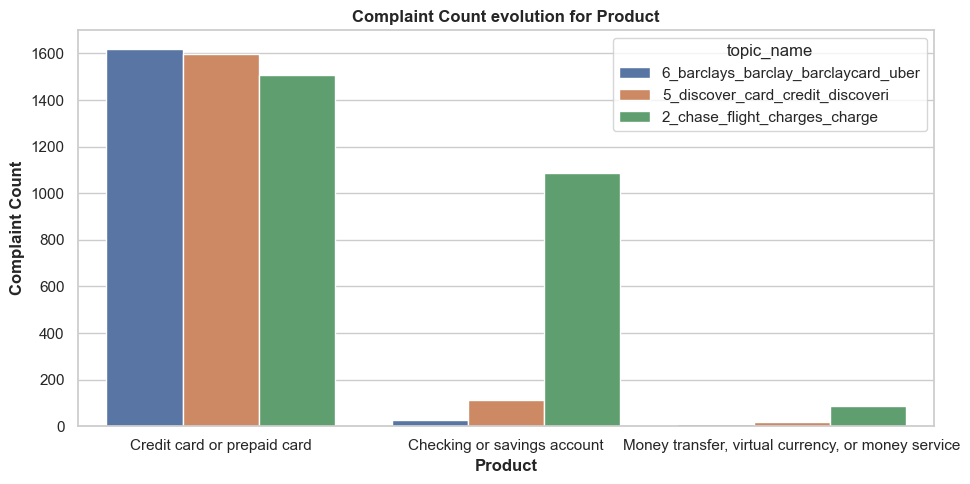

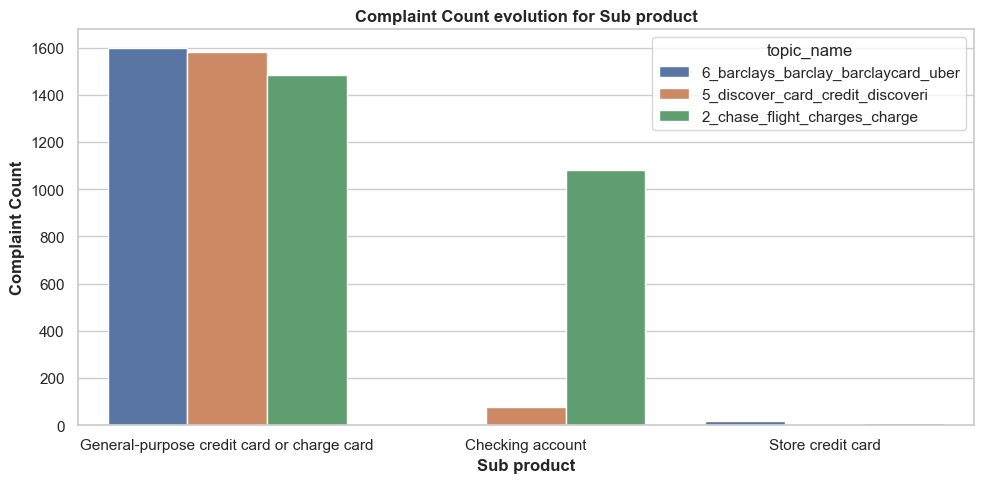

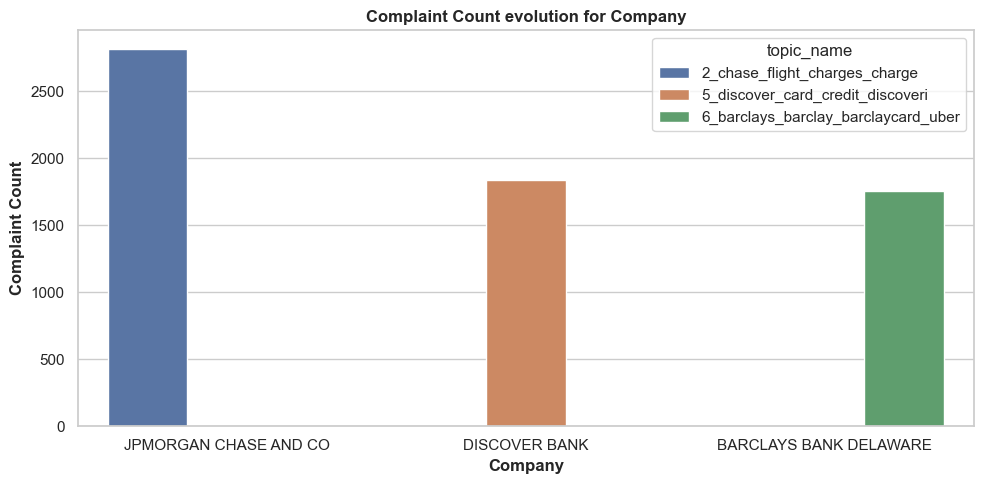

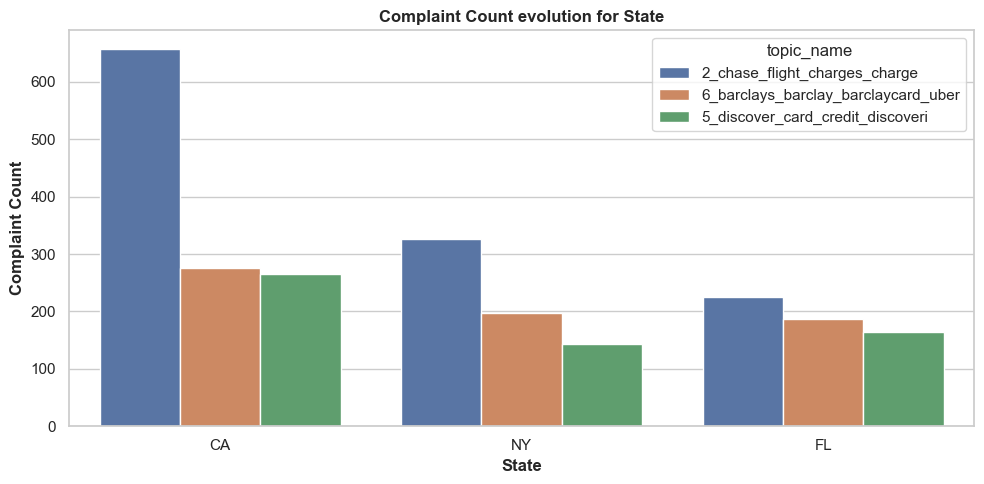

In [25]:
# Frauduent Topics Investigation
visualize_features = ['product', 'sub_product', 'company', 'state']

for feature in visualize_features:
    N_features = 3
    
    grouped = merged.groupby(['topic_name', feature], as_index=False)['complaint_id'].nunique()
    grouped.rename(columns={'complaint_id':'complaint_count'}, inplace=True)

    if grouped[feature].nunique() < N_features:
        N_features = grouped[feature].nunique()
    
    top_features = grouped.groupby(feature, as_index=False)['complaint_count'].sum()
    top_features = top_features.sort_values(by=['complaint_count'], ascending=False)[feature].head(N_features)

    top_topics = grouped.groupby('topic_name', as_index=False)['complaint_count'].sum()
    top_topics = top_topics.sort_values(by=['complaint_count'], ascending=False)['topic_name'].head(N_features)
    
    grouped = grouped[grouped[feature].isin(top_features) & grouped['topic_name'].isin(top_topics)].sort_values(by=['complaint_count'], ascending=False)

    plt.figure(figsize=(10,5))
    sns.barplot(data=grouped,
                x=feature,
                y='complaint_count',
                hue='topic_name'
               )
    if N_features > 4:
        plt.title(f'Complaint Count evolution for {feature.replace('_', ' ').capitalize()} Top {N_features}', fontweight='bold')
    else:
        plt.title(f'Complaint Count evolution for {feature.replace('_', ' ').capitalize()}', fontweight='bold')
    plt.xlabel(f'{feature.replace('_', ' ').capitalize()}', fontweight='bold')
    plt.ylabel('Complaint Count', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()